In [ ]:
import os
import time
import joblib
import glob
import numpy as np
import pandas as pd
from pathlib import Path

import xgboost as xgb
from sklearn import metrics 
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import ndcg_score, r2_score, mean_squared_error

from skopt.acquisition import gaussian_ei, gaussian_lcb
from scipy.stats       import rankdata
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, rankdata

import utils

In [2]:
save = True
name = "CrTeNW_data"

root_dir = str(Path(os.getcwd()))
from_dir = root_dir + "/data/"
to_dir = root_dir + "/results/"

df_cleaned, X, Y, clean_feature_list, clean_result_col = utils.load_and_clean_data(name, feature_col_num=0, target="length")


Initial dataset size: 94
Feature list: ['Te', 'Size', 'Ar', 'H_2', 'R_temp', 'G_temp', 'G_time', 'Q_Pre']
Yield column (for duplicate resolution): Yield

Number of Removed Duplicated Rows:  0

Loading CrTeNW_data dataset...
Features list: ['Te', 'Size', 'Ar', 'H_2', 'R_temp', 'G_temp', 'G_time', 'Q_Pre']
Feature size: 8
Dataset size: 94
Target column: Length
Sum of target values: 733.4399999999999
Mean of target values: 7.802553191489361
Y non-zero: 45 
Y zero: 49


# Best Model Parameter Generation

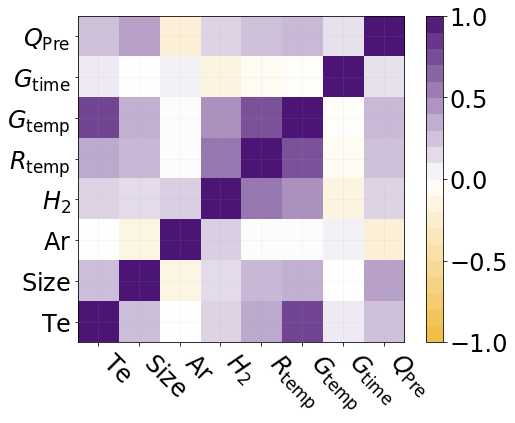

In [3]:
utils.plot_correlation_matrix(X, name, clean_feature_list, toSaveFig = False)

In [4]:
def test(y_pred, y_true, k=None, verbose=False):
    """
    Evaluate the performance of a regression model using R², MSE, Pearson correlation, p-value, and nDCG.
    Also tracks the index of the data point with the largest loss.

    Parameters:
        y_pred : array-like
            Predicted target values.
        y_true : array-like
            Ground truth target values.
        k : int, optional (default=10)
            The number of top results to consider for nDCG evaluation.
        verbose : bool, optional (default=False)
            If True, prints rankings, actual values, predicted values, and largest loss details.

    Returns:
        metrics_array : np.array
            [r², mse, pearson, pearson_p_value, ndcg_score].
        max_loss_index : int
            Index of the data point with the largest loss.
    """
    # Ensure inputs are NumPy arrays
    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    
    if y_pred.shape != y_true.shape:
        raise ValueError("y_pred and y_true must have the same shape.")
    
    if len(y_pred) == 0:
        raise ValueError("Input arrays must not be empty.")
    
    # R² and MSE
    r2 = metrics.r2_score(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    
    # Pearson correlation and p-value
    pear, p_value = pearsonr(y_true, y_pred)
    
    # Generate rankings with ties
    true_ranking = rankdata(-y_true, method="min")  # Higher values get lower ranks
    pred_ranking = rankdata(-y_pred, method="min")  # Higher predicted values get lower ranks

    # Compute nDCG using relevance scores
    ndcg = ndcg_score([y_true], [y_pred], k=k)
    
    # Identify the index of the largest loss
    losses = np.abs(y_pred - y_true)
    max_loss_index = np.argmax(losses)
    
    if verbose:
        print("True Ranking:", true_ranking)
        print("Predicted Ranking:", pred_ranking)
        print(f"Largest Loss: {losses[max_loss_index]} at Index: {max_loss_index}")
        print("\nActual Values:")
        print(y_true)
        print("\nPredicted Values:")
        print(y_pred)
    
    return np.array([r2, mse, pear, p_value, ndcg]), max_loss_index

def run_xgb_regression(
    X,
    Y,
    df_cleaned,
    to_dir,
    name,
    test_function,       # now: (y_pred, y_true, k=None, verbose=False)
    Ntrials=10,
    outer_nsplit=5,
    inner_nsplit=5,
    verbose=False,
    save_csv=True,
    n_jobs=8,
    save_models=False,
    toSaveFig=True,
    batch=1               # ← passed as k to nDCG
):
    tot_count = Ntrials * outer_nsplit
    xgb_mat   = np.zeros((tot_count, 5))
    xgb_predictions = []
    best_models     = []

    for i in range(Ntrials):
        init_time = time.time()
        print(f"\nTrial {i+1}/{Ntrials}")

        outer_cv = KFold(n_splits=outer_nsplit, shuffle=True, random_state=i)
        splits   = list(outer_cv.split(X, Y))

        for j, (train_idx, test_idx) in enumerate(splits):
            count = i * outer_nsplit + j
            print(f"  Fold {j+1}/{outer_nsplit}  (global idx {count+1}/{tot_count})")

            # split train/test
            X_train, Y_train = X[train_idx], Y[train_idx]
            X_test,  Y_test  = X[test_idx],  Y[test_idx]
            test_indices     = df_cleaned.index[test_idx]
            test_features    = df_cleaned.loc[test_indices]

            # hyperparameter search
            inner_cv = KFold(n_splits=inner_nsplit, shuffle=True, random_state=j)
            base = xgb.XGBRegressor(objective="reg:linear", n_jobs=n_jobs,
                                    random_state=3, seed=3)
            tuned_parameters = {
                'learning_rate': [0.01, 0.1, 1],
                'n_estimators':  [300, 500, 700],
                'colsample_bylevel': [0.5, 0.7, 0.9],
                'gamma':         [0, 0.2],
                'max_depth':     [3, 7, 11],
                'reg_lambda':    [0.1, 1, 10],
                'subsample':     [0.4, 0.7, 1]
            }
            xgb_cv = GridSearchCV(
                base, tuned_parameters,
                cv=inner_cv, scoring="r2",
                verbose=verbose, n_jobs=n_jobs
            )
            xgb_cv.fit(X_train, Y_train)

            # best model
            best_model = xgb_cv.best_estimator_
            best_models.append(best_model)

            # predict & evaluate
            y_pred = best_model.predict(X_test)
            metrics_array, max_loss_index = test_function(
                y_pred, Y_test, k=batch, verbose=False
            )
            xgb_mat[count] = metrics_array

            # collect for export
            df_pred = pd.DataFrame({
                "Index":     test_indices,
                "Actual":    Y_test,
                "Predicted": y_pred
            })
            df_pred = pd.concat(
                [test_features.reset_index(drop=True),
                 df_pred.reset_index(drop=True)],
                axis=1
            )
            xgb_predictions.append(df_pred)

            # optionally save the model
            if save_models:
                pkl_dir = os.path.join(to_dir, "pkl_files")
                os.makedirs(pkl_dir, exist_ok=True)
                fn = f"model_{name}_trial{i}_fold{j}.pkl"
                joblib.dump(best_model, os.path.join(pkl_dir, fn))

        # end folds
        elapsed = (time.time() - init_time) / 60
        print(f"  Completed Trial {i} in {elapsed:.2f} min")

    # aggregate predictions
    xgb_predictions_df = pd.concat(xgb_predictions).sort_values("Index")
    if save_csv:
        path_pred = os.path.join(to_dir, f"xgb_predictions_{name}.csv")
        xgb_predictions_df.to_csv(path_pred, index=False)

    # results DataFrame
    cols        = ['r2', 'mse', 'pearson', 'pearson_p', 'ndcg']
    xgb_results = pd.DataFrame(xgb_mat, columns=cols)
    if save_csv:
        path_res = os.path.join(to_dir, f"xgb_results_{name}.csv")
        xgb_results.to_csv(path_res, index=False)

    # optional boxplot
    if toSaveFig:
        utils.plot_boxplots(
            [xgb_results],
            ylabels=['XGBoost-Reg'],
            xmin=-0.025,
            toSaveFig=True,
            title=f"{name}_boxplot"
        )

    # print summary metrics
    mean_m = xgb_results.mean()
    std_m  = xgb_results.std()
    print("\nMean metrics:\n", mean_m)
    print("Std  metrics:\n", std_m)

    return xgb_results, xgb_predictions_df, best_models


In [ ]:
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
X = X_normalized

Ntrials = 10
outer_nsplit = 5
inner_nsplit = 5
n_jobs = 6 #Running on 6 cores took around 1 hours for this, please notice

# Nested CV Xgboost
xgb_results, xgb_predictions_df, best_models = run_xgb_regression(
    X,
    Y,
    df_cleaned,
    to_dir,
    name,
    test_function=test,
    Ntrials=Ntrials,
    outer_nsplit=outer_nsplit,
    inner_nsplit=inner_nsplit,
    verbose=0,
    save_csv=True,
    n_jobs=n_jobs,
    save_models=True,
    toSaveFig=False
)

print(f"\nTotal best_models returned: {len(best_models)}")

# Pick best‐performing fold
trial_best_models = []
for trial in range(Ntrials):
    start_idx = trial * outer_nsplit
    end_idx   = start_idx + outer_nsplit
    trial_r2 = xgb_results['r2'].iloc[start_idx:end_idx].values
    local_best_fold = int(np.argmax(trial_r2))
    global_best_idx = start_idx + local_best_fold
    trial_best_models.append(best_models[global_best_idx])

    print(
        f"Trial {trial}: Best r2 = {trial_r2[local_best_fold]:.3f} "
        f"(global fold index {global_best_idx})"
    )

# Save Result
best_models_dir = os.path.join(to_dir, "best_models")
os.makedirs(best_models_dir, exist_ok=True)

for trial, model in enumerate(trial_best_models):
    filename = os.path.join(best_models_dir, f"best_model_trial_{trial}.pkl")
    filename_i=f"best_model_trial_{trial}.pkl"
    joblib.dump(model, filename)
    print(f"Saved Trial {trial} best model in results/best_models as {filename_i}")


Trial 1/10
  Fold 1/5  (global idx 1/50)
  Fold 2/5  (global idx 2/50)
  Fold 3/5  (global idx 3/50)
  Fold 4/5  (global idx 4/50)
  Fold 5/5  (global idx 5/50)
  Completed Trial 0 in 5.49 min

Trial 2/10
  Fold 1/5  (global idx 6/50)
  Fold 2/5  (global idx 7/50)
  Fold 3/5  (global idx 8/50)
  Fold 4/5  (global idx 9/50)
  Fold 5/5  (global idx 10/50)
  Completed Trial 1 in 5.45 min

Trial 3/10
  Fold 1/5  (global idx 11/50)
  Fold 2/5  (global idx 12/50)
  Fold 3/5  (global idx 13/50)
  Fold 4/5  (global idx 14/50)
  Fold 5/5  (global idx 15/50)
  Completed Trial 2 in 5.45 min

Trial 4/10
  Fold 1/5  (global idx 16/50)
  Fold 2/5  (global idx 17/50)
  Fold 3/5  (global idx 18/50)
  Fold 4/5  (global idx 19/50)
  Fold 5/5  (global idx 20/50)
  Completed Trial 3 in 5.39 min

Trial 5/10
  Fold 1/5  (global idx 21/50)
  Fold 2/5  (global idx 22/50)
  Fold 3/5  (global idx 23/50)
  Fold 4/5  (global idx 24/50)
  Fold 5/5  (global idx 25/50)
  Completed Trial 4 in 5.48 min

Trial 6/10
  

# Shuffled Model Generation

In [ ]:
import re

# Load best trial models 
models_dir = os.path.join(to_dir, "best_models")
model_files = sorted([
    f for f in os.listdir(models_dir)
    if re.match(r'best_model_trial_\d+\.pkl$', f)
], key=lambda x: int(re.search(r'_(\d+)\.pkl$', x).group(1)))

trial_best_models = []
for fname in model_files:
    path = os.path.join(models_dir, fname)
    trial_best_models.append(joblib.load(path))
    print(f"Loaded: {fname}")
print(f"\nTotal best models loaded: {len(trial_best_models)}")

shuffled_model_dir = os.path.join(to_dir, "shuffled_models")
os.makedirs(shuffled_model_dir, exist_ok=True)

Loaded: best_model_trial_0.pkl
Loaded: best_model_trial_1.pkl
Loaded: best_model_trial_2.pkl
Loaded: best_model_trial_3.pkl
Loaded: best_model_trial_4.pkl
Loaded: best_model_trial_5.pkl
Loaded: best_model_trial_6.pkl
Loaded: best_model_trial_7.pkl
Loaded: best_model_trial_8.pkl
Loaded: best_model_trial_9.pkl

Total best models loaded: 10


In [ ]:
# Re-train on shuffled data
num_runs       = 10
all_results    = []
all_predictions = []

for run_id in range(num_runs):
    print(f"\n=== Run {run_id+1}/{num_runs} ===")
    # Shuffle the cleaned DataFrame
    df_shuf = df_cleaned.sample(frac=1, random_state=42 + run_id).reset_index(drop=True)
    X_shuf  = df_shuf[clean_feature_list].values
    Y_shuf  = df_shuf[clean_result_col].values

    # Split for evaluation
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_shuf, Y_shuf, test_size=0.3, random_state=42
    )

    run_results     = {}
    run_predictions = {}

    # Loop over each trial’s best model
    for idx, base_model in enumerate(trial_best_models):
        params    = base_model.get_params()
        new_model = xgb.XGBRegressor(**{
            k: v for k, v in params.items()
            if k in xgb.XGBRegressor().get_params()
        })
        new_model.fit(X_train, Y_train)
        y_pred = new_model.predict(X_test)
        r2  = r2_score(Y_test, y_pred)
        mse = mean_squared_error(Y_test, y_pred)

        run_results[f"model_{idx}"] = {"r2": r2, "mse": mse}
        run_predictions[f"model_{idx}"] = pd.DataFrame({"Actual": Y_test,"Predicted": y_pred})

        # Save the retrained model
        out_path = os.path.join(
            shuffled_model_dir,
            f"run_{run_id}_model_{idx}.pkl"
        )

        file_output = f"run_{run_id}_model_{idx}.pkl"

        joblib.dump(new_model, out_path)
        print(f"Run {run_id} | model_{idx} → R²={r2:.3f}, MSE={mse:.3f} | saved in results/shuffled_models as {file_output}")

    all_results.append(pd.DataFrame(run_results).T)
    all_predictions.append(run_predictions)


=== Run 1/10 ===
Run 0 | model_0 → R²=0.586, MSE=36.443 | saved in results/shuffled_models as run_0_model_0.pkl
Run 0 | model_1 → R²=0.619, MSE=33.554 | saved in results/shuffled_models as run_0_model_1.pkl
Run 0 | model_2 → R²=0.609, MSE=34.380 | saved in results/shuffled_models as run_0_model_2.pkl
Run 0 | model_3 → R²=0.464, MSE=47.165 | saved in results/shuffled_models as run_0_model_3.pkl
Run 0 | model_4 → R²=0.344, MSE=57.723 | saved in results/shuffled_models as run_0_model_4.pkl
Run 0 | model_5 → R²=0.592, MSE=35.882 | saved in results/shuffled_models as run_0_model_5.pkl
Run 0 | model_6 → R²=0.343, MSE=57.843 | saved in results/shuffled_models as run_0_model_6.pkl
Run 0 | model_7 → R²=0.081, MSE=80.850 | saved in results/shuffled_models as run_0_model_7.pkl
Run 0 | model_8 → R²=0.595, MSE=35.635 | saved in results/shuffled_models as run_0_model_8.pkl
Run 0 | model_9 → R²=0.504, MSE=43.666 | saved in results/shuffled_models as run_0_model_9.pkl

=== Run 2/10 ===
Run 1 | model_

In [ ]:
# Combine & inspect 
combined_results = pd.concat(
    all_results,
    keys=[f"run_{i}" for i in range(num_runs)],
    names=["run", "model"]
)
print("\nCombined Results:")
print(combined_results)

# (Optional) Flatten all predictions into one DataFrame
flat_preds = []
for run_id, preds in enumerate(all_predictions):
    for model_key, df_pred in preds.items():
        df_pred["run"]   = run_id
        df_pred["model"] = model_key
        flat_preds.append(df_pred)
flat_predictions_df = pd.concat(flat_preds, ignore_index=True)


Combined Results:
                     r2        mse
run   model                       
run_0 model_0  0.585851  36.442948
      model_1  0.618680  33.554226
      model_2  0.609294  34.380142
      model_3  0.464004  47.164909
      model_4  0.344013  57.723483
...                 ...        ...
run_9 model_5  0.681672  27.668350
      model_6  0.695337  26.480662
      model_7  0.757274  21.097183
      model_8  0.712975  24.947593
      model_9  0.723215  24.057503

[100 rows x 2 columns]


# MSS Generation

In [13]:
def list_generator(start: float, end: float, step: float):
    scaled = range(int(start*100), int(end*100), int(step*100))
    seq    = [x/100.0 for x in scaled] + [end]
    return [round(x, 2) for x in seq]

def generate_mss_grid(
    ranges: dict,
    output_dir: str,
    output_filename: str = "MSS_CrTe.csv",
    save_csv: bool = True
) -> pd.DataFrame:
    """
    Generate the full Cartesian-product grid of parameter combinations.

    Parameters
    ----------
    ranges          : dict - A mapping from feature name to a tuple (start, end, step).
    output_dir      : str - Directory where the CSV will be saved.
    output_filename : str, optional - Name of the CSV file.
    save_csv        : bool, optional - Whether to save the DataFrame to CSV (default True).

    Returns
    -------
    pd.DataFrame
        The DataFrame containing every combination.
    """

    # 1) generate each parameter list
    param_lists = {
        name: list_generator(*params)
        for name, params in ranges.items()
    }

    # 2) print lengths and total combinations
    lengths = {name: len(vals) for name, vals in param_lists.items()}
    total = np.prod(list(lengths.values()), dtype=int)
    print("Generated parameter lengths:")
    for name, ln in lengths.items():
        print(f"  {name}: {ln}")
    print(f"  → Total combinations: {total}\n")

    # 3) build the meshgrid and reshape into (N, n_features)
    grid = np.meshgrid(*param_lists.values(), indexing="ij")
    combos = np.stack(grid, axis=-1).reshape(-1, len(grid))

    # 4) assemble DataFrame
    df = pd.DataFrame(combos, columns=list(param_lists.keys()))

    # 5) save to CSV if requested
    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        out_path = os.path.join(output_dir, output_filename)
        df.to_csv(out_path, index=False)
        print(f"Saved {len(df)} rows in data as {output_filename}")

    return df

ranges = {
    "Te":     (0,   1.6, 0.2),
    "Size":   (3,   6,   1  ),
    "Ar":     (60,  200, 20 ),
    "H_2":    (0,   40,  2  ),
    "R_temp": (610, 850, 20 ),
    "G_temp": (610, 850, 20 ),
    "G_time": (0,   30,  5  ),
    "Q_Pre":  (1,   3,   1  )
}


In [ ]:
# Compute number of points in each 1D range
lengths = {
    name: int((end - start) / step) + 1
    for name, (start, end, step) in ranges.items()
}

print("Points per parameter:")
for name, cnt in lengths.items():
    print(f"  {name}: {cnt}")

total_combinations = int(np.prod(list(lengths.values())))
print(f"\nTotal number of combinations: {total_combinations}")

Points per parameter:
  Te: 9
  Size: 4
  Ar: 8
  H_2: 21
  R_temp: 13
  G_temp: 13
  G_time: 7
  Q_Pre: 3

Total number of combinations: 21464352


In [ ]:
# Generate & save the full MSS grid
df_grid = generate_mss_grid(
    ranges=ranges,
    output_dir=from_dir,
    output_filename=f"MSS_{name}.csv",
    save_csv=True
)

# Load tested MSS points
df_tested   = df_cleaned

# Only keep the MSS feature columns
feature_cols = list(ranges.keys())
tested_feats = (
    df_tested[feature_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)
print(f"Loaded {len(tested_feats)} unique tested combinations")


# Anti-join to remove tested combos from the grid
df_untested = (
    df_grid
      .merge(tested_feats, on=feature_cols, how="left", indicator=True)
      .query("_merge == 'left_only'")
      .drop(columns="_merge")
)
dropped  = len(df_grid) - len(df_untested)
remaining = len(df_untested)
print(f"Dropped {dropped} tested combos; {remaining} remain untested.\n")

out_path = os.path.join(from_dir, f"MSS_{name}_untested.csv")
out_filename = f"MSS_{name}_untested.csv"
df_untested.to_csv(out_path, index=False)

print(f"Saved untested grid ({remaining} rows) in data as {out_filename}")

Generated parameter lengths:
  Te: 9
  Size: 4
  Ar: 8
  H_2: 21
  R_temp: 13
  G_temp: 13
  G_time: 7
  Q_Pre: 3
  → Total combinations: 21464352

Saved 21464352 rows in data as MSS_CrTe.csv
Loaded 94 unique tested combinations
Dropped 0 tested combos; 21464352 remain untested.

Saved untested grid (21464352 rows) in data as  MSS_CrTe_untested.csv


# MSS prediction

In [ ]:
shuffled_models_dir = os.path.join(to_dir, "shuffled_models")
MSS_input_path     = os.path.join(from_dir, "MSS_CrTe_untested.csv")
chunk_size          = 1_000_000            # adjust as needed

mss_feature_list    = clean_feature_list   # feature columns
mss_result_col      = clean_result_col     # true target

output_chunks_dir   = os.path.join(to_dir, "chunk_metrics")
os.makedirs(output_chunks_dir, exist_ok=True)

# acquisition-function hyper-parameters
acq_func        = "LCB"     # choose: "EI", "LCB", "MOCU_mean", "MOCU_std_dev", "rank_score"
expl_ratio      = 0.10     # xi = expl_ratio * mean(σ)  (EI)
kappa_base      = 1.44     # kappa                     (LCB)
alpha, beta     = 0.9, 0.1 # weights                   (rank_score)

In [ ]:
# Load every shuffled model
model_paths   = sorted(
    glob.glob(os.path.join(shuffled_models_dir, "*.pkl")),
    key=lambda p: int(os.path.splitext(os.path.basename(p))[0].split("_")[1])
)
loaded_models = [joblib.load(p) for p in model_paths]
print(f"Loaded {len(loaded_models)} regression models.")


# Stream the CSV in chunks
reader = pd.read_csv(MSS_input_path, chunksize=chunk_size)

Loaded 100 regression models.


In [ ]:
for chunk_idx, df_chunk in enumerate(reader):
    print(f"\nProcessing chunk {chunk_idx} ({len(df_chunk)} rows)…")

    # Ensemble predictions
    X_chunk   = df_chunk[mss_feature_list].values
    all_preds = np.vstack([mdl.predict(X_chunk) for mdl in loaded_models])  # (n_models, n_rows)
    #all_preds_list.append(all_preds)

    mu    = all_preds.mean(axis=0)         
    sigma = all_preds.std(axis=0, ddof=1)   

    # Acquisition values
    class DummyModel:
        def __init__(self, mean, std):
            self.mean = mean
            self.std  = std
        def predict(self, X, return_std=False):
            return (self.mean, self.std) if return_std else self.mean

    dummy      = DummyModel(-mu, sigma)                  # negative for maximisation → minimisation
    candidates = -mu.reshape(-1, 1)                      

    acq = {}
    # EI
    xi   = sigma.mean() * expl_ratio
    yopt = -mu.max()
    acq["EI"] = gaussian_ei(candidates, dummy, y_opt=yopt, xi=xi, return_grad=False)
    # LCB  (smaller is better)
    acq["LCB"] = gaussian_lcb(candidates, dummy, kappa=kappa_base, return_grad=False)
    # MOCU proxies
    acq["MOCU_mean"]    =  mu
    acq["MOCU_std_dev"] =  sigma
    # rank-score
    rk_pred = rankdata(mu,    method="max")   # higher μ ⇒ smaller rank index
    rk_unc  = rankdata(sigma, method="max")   # higher σ ⇒ smaller rank index
    acq["rank_score"] = alpha * rk_pred + beta * rk_unc

    # Pick index for chosen acquisition
    pick_idx = np.argmin(acq["LCB"]) if acq_func == "LCB" else np.argmax(acq[acq_func])
    global_idx = df_chunk.index[pick_idx]
    print(f"  {acq_func} selects global row {global_idx} (μ={mu[pick_idx]:.4f}, σ={sigma[pick_idx]:.4f})")

    df_feats = df_chunk[mss_feature_list].reset_index(drop=True)

    # Save per-row μ, σ & all acq vectors
    df_out = pd.DataFrame(df_feats)
    df_out["global_idx"] = df_chunk.index.values
    df_out["pred_mean"]  = mu          # ensemble mean prediction
    df_out["pred_std"]   = sigma       # ensemble std-dev

    for name, vals in acq.items():
        df_out[name] = vals

    out_acq = os.path.join(output_chunks_dir, f"chunk_{chunk_idx}_acq.csv")
    out_acq_name = f"chunk_{chunk_idx}_acq.csv"
    df_out.to_csv(out_acq, index=False)
    print(f"  • Saved per-row acquisition values + features → {out_acq_name}")

    # Save chunk-level summary (mean & std of μ)
    metrics_df = pd.DataFrame({
        "chunk_idx": [chunk_idx],
        "n_rows":    [len(df_chunk)],
        "mean_mu":   [mu.mean()],
        "std_mu":    [mu.std(ddof=1)]
    })
    out_metric = os.path.join(output_chunks_dir, f"chunk_{chunk_idx}_metrics.csv")
    out_metric_name = f"chunk_{chunk_idx}_metrics.csv"
    metrics_df.to_csv(out_metric, index=False)
    print(f"  • Saved chunk summary          → {out_metric_name}")


Processing chunk 0 (1000000 rows)…
  LCB selects global row 659456 (μ=10.3539, σ=5.5745)
  • Saved per-row acquisition values + features → chunk_0_acq.csv
  • Saved chunk summary          → chunk_0_metrics.csv

Processing chunk 1 (1000000 rows)…
  LCB selects global row 1255688 (μ=10.2707, σ=5.5948)
  • Saved per-row acquisition values + features → chunk_1_acq.csv
  • Saved chunk summary          → chunk_1_metrics.csv

Processing chunk 2 (1000000 rows)…
  LCB selects global row 2448152 (μ=10.3526, σ=5.3185)
  • Saved per-row acquisition values + features → chunk_2_acq.csv
  • Saved chunk summary          → chunk_2_metrics.csv

Processing chunk 3 (1000000 rows)…
  LCB selects global row 3044384 (μ=10.3539, σ=5.5745)
  • Saved per-row acquisition values + features → chunk_3_acq.csv
  • Saved chunk summary          → chunk_3_metrics.csv

Processing chunk 4 (1000000 rows)…
  LCB selects global row 4833080 (μ=10.3707, σ=5.3280)
  • Saved per-row acquisition values + features → chunk_4_acq.

# Top Acqusition Sampling

In [ ]:
# Load the full MSS grid and set up merge key 
MSS_input_path = os.path.join(from_dir, 'MSS_CrTe_untested.csv')
df_mss = pd.read_csv(MSS_input_path)

df_mss.reset_index(drop=False, inplace=True)
df_mss.rename(columns={"index": "global_idx"}, inplace=True)


# Find all per‐chunk acquisition files
chunk_acq_dir = os.path.join(to_dir, "chunk_metrics")
chunk_files   = sorted(glob.glob(os.path.join(chunk_acq_dir, "chunk_*_acq.csv")))

acq_funcs = ["EI", "MOCU_mean", "MOCU_std_dev", "rank_score", "LCB"]
TOP_N     = 100   # number of samples to pick per acquisition

In [ ]:
# Loop over each acquisition for top list
for acq in acq_funcs:
    print(f"\nSampling top {TOP_N} by {acq}…")
    global_top = pd.DataFrame()

    for path in chunk_files:
        df_chunk = pd.read_csv(path, low_memory=True)

        # Pick the best TOP_N in this chunk
        if acq == "LCB":
            partial = df_chunk.nsmallest(TOP_N, acq)
        else:
            partial = df_chunk.nlargest(TOP_N, acq)

        global_top = pd.concat([global_top, partial], ignore_index=True)
        if acq == "LCB":
            global_top = global_top.nsmallest(TOP_N, acq)
        else:
            global_top = global_top.nlargest(TOP_N, acq)

        del df_chunk

    print(f"  → Collected {len(global_top)} candidates (trimmed to {TOP_N}).")

    if len(global_top) > TOP_N:
        if acq == "LCB":
            final_top = global_top.nsmallest(TOP_N, acq)
        else:
            final_top = global_top.nlargest(TOP_N, acq)
    else:
        final_top = global_top.copy()

    # Merge back the full MSS features 
    df_top_with_features = final_top.merge(df_mss, on="global_idx", how="left")

    out_path = os.path.join(to_dir, f"top{TOP_N}_{acq}.csv")
    out_filename = f"top{TOP_N}_{acq}.csv"
    df_top_with_features.to_csv(out_path, index=False)
    print(f"  • Saved top {TOP_N} by {acq} → result/{out_filename}")


Sampling top 100 by EI…
  → Collected 100 candidates (trimmed to 100).
  • Saved top 100 by EI → result/top100_EI.csv

Sampling top 100 by MOCU_mean…
  → Collected 100 candidates (trimmed to 100).
  • Saved top 100 by MOCU_mean → result/top100_MOCU_mean.csv

Sampling top 100 by MOCU_std_dev…
  → Collected 100 candidates (trimmed to 100).
  • Saved top 100 by MOCU_std_dev → result/top100_MOCU_std_dev.csv

Sampling top 100 by rank_score…
  → Collected 100 candidates (trimmed to 100).
  • Saved top 100 by rank_score → result/top100_rank_score.csv

Sampling top 100 by LCB…
  → Collected 100 candidates (trimmed to 100).
  • Saved top 100 by LCB → result/top100_LCB.csv


In [22]:
top_score = pd.read_csv('results/top100_LCB.csv')
top_score_sorted = top_score.sort_values(by='LCB', ascending=True)
top_3_lcb = top_score_sorted.head(3)
print(top_3_lcb)

   Te_x  Size_x   Ar_x  H_2_x  R_temp_x  G_temp_x  G_time_x  Q_Pre_x  \
0   1.2     4.0   60.0   34.0     770.0     750.0      20.0      3.0   
1   1.2     4.0   80.0   34.0     770.0     750.0      20.0      3.0   
2   1.2     4.0  100.0   34.0     770.0     750.0      20.0      3.0   

   global_idx  pred_mean  ...  MOCU_std_dev  rank_score  Te_y  Size_y   Ar_y  \
0    14968478   20.40286  ...      6.521294    996005.6   1.2     4.0   60.0   
1    15043007   20.40286  ...      6.521294    999577.7   1.2     4.0   80.0   
2    15117536   20.40286  ...      6.521294    999577.7   1.2     4.0  100.0   

   H_2_y  R_temp_y  G_temp_y  G_time_y  Q_Pre_y  
0   34.0     770.0     750.0      20.0      3.0  
1   34.0     770.0     750.0      20.0      3.0  
2   34.0     770.0     750.0      20.0      3.0  

[3 rows x 24 columns]


# Mixture of Acqusition Function (extension from this project)

In [ ]:
from collections import Counter

acq_funcs = ["EI", "MOCU_mean", "MOCU_std_dev", "rank_score", "LCB"]
TOP_N     = 100
MSS_input_path = os.path.join(from_dir, "MSS_CrTe_untested.csv")
df_mss = pd.read_csv(MSS_input_path)
df_mss.reset_index(drop=False, inplace=True)
df_mss.rename(columns={"index": "global_idx"}, inplace=True)
top_dir = to_dir

In [ ]:
# Load each top‐N file into a dict
idx_sets = {}
top_df   = {}  

for acq in acq_funcs:
    path = os.path.join(top_dir, f"top{TOP_N}_{acq}.csv")
    df   = pd.read_csv(path)
    idx_sets[acq] = set(df["global_idx"])
    top_df[acq]    = df
    print(f"Loaded {len(df)} rows from {os.path.basename(path)}")

# Count appearances & pick those >1
counter = Counter(idx for s in idx_sets.values() for idx in s)
repeated_idx = [idx for idx, cnt in counter.items() if cnt > 1]
print(f"\nFound {len(repeated_idx)} indices chosen by ≥2 acquisitions")


Loaded 100 rows from top100_EI.csv
Loaded 100 rows from top100_MOCU_mean.csv
Loaded 100 rows from top100_MOCU_std_dev.csv
Loaded 100 rows from top100_rank_score.csv
Loaded 100 rows from top100_LCB.csv

Found 63 indices chosen by ≥2 acquisitions


In [ ]:
# Build summary with pred_mean & which acqs picked them 
summary = []
for idx in repeated_idx:
    chosen = [acq for acq in acq_funcs if idx in idx_sets[acq]]
    means = [
        top_df[acq].loc[top_df[acq]["global_idx"] == idx, "pred_mean"].iloc[0]
        for acq in chosen
    ]
    pred_mean = np.mean(means)
    summary.append({
        "global_idx": idx,
        "count":      counter[idx],
        "acq_funcs":  ",".join(chosen),
        "pred_mean":  pred_mean
    })

df_repeated = pd.DataFrame(summary)

# Merge back full MSS features
df_repeated_full = df_repeated.merge(df_mss, on="global_idx", how="left")

out_path = os.path.join(to_dir, "repeated_candidates_with_mean.csv")
out_filename = "repeated_candidates_with_mean.csv"
df_repeated_full.to_csv(out_path, index=False)
print(f"Saved repeated candidates with predicted mean in results as {out_filename}")
print(df_repeated_full.head())

Saved repeated candidates with predicted mean → repeated_candidates_with_mean.csv
   global_idx  count      acq_funcs  pred_mean   Te  Size     Ar   H_2  \
0      659456      2  EI,rank_score  10.353890  0.0   4.0   60.0  34.0   
1    18102791      2         EI,LCB  20.430151  1.4   5.0  100.0  36.0   
2    18098696      2         EI,LCB  20.138990  1.4   5.0  100.0  34.0   
3    15714314      2         EI,LCB  20.665611  1.2   5.0  100.0  34.0   
4     3044384      2  EI,rank_score  10.353890  0.2   4.0   60.0  34.0   

   R_temp  G_temp  G_time  Q_Pre  
0   810.0   750.0    20.0    3.0  
1   810.0   750.0    20.0    3.0  
2   770.0   750.0    20.0    3.0  
3   810.0   750.0    20.0    3.0  
4   810.0   750.0    20.0    3.0  
